В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [13]:
!pip install opendatasets --upgrade --quiet

In [14]:
import opendatasets as od
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
import joblib

In [15]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data?select=sample_submission.csv'

In [16]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-3" (use force=True to force download)


In [17]:
dataset_url_2 = 'https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction'

In [18]:
od.download(dataset_url_2)

Skipping, found downloaded files in "./bank-customer-churn-prediction" (use force=True to force download)


Area under ROC score on Training dataset: 0.77%


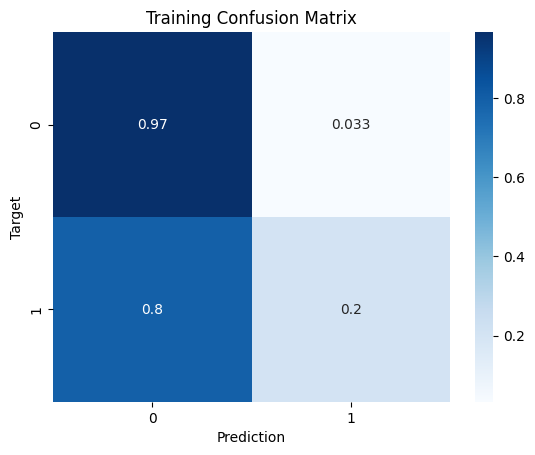

Area under ROC score on Validation dataset: 0.77%


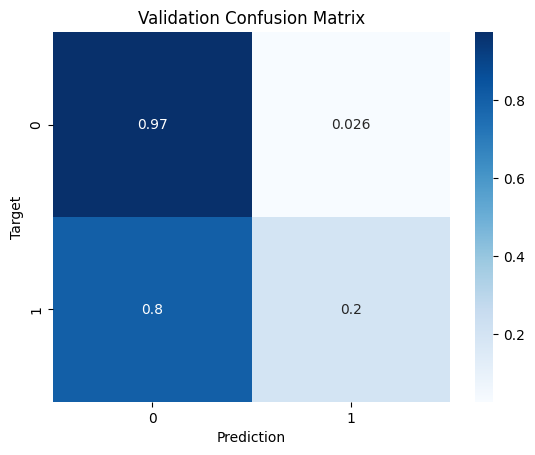

['log_reg.joblib']

In [19]:
raw_df = pd.read_csv('/content/bank-customer-churn-prediction/Churn_Modelling.csv', index_col=0)

# Створюємо трен. і вал. набори
input_cols = raw_df.drop(['CustomerId', 'Surname', 'Exited'], axis=1).columns.to_list()
target_col = 'Exited'
train_inputs, val_inputs, train_targets, val_targets  = train_test_split(raw_df[input_cols], raw_df[target_col], test_size=0.2, random_state=17)

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Training dataset: 0.83%


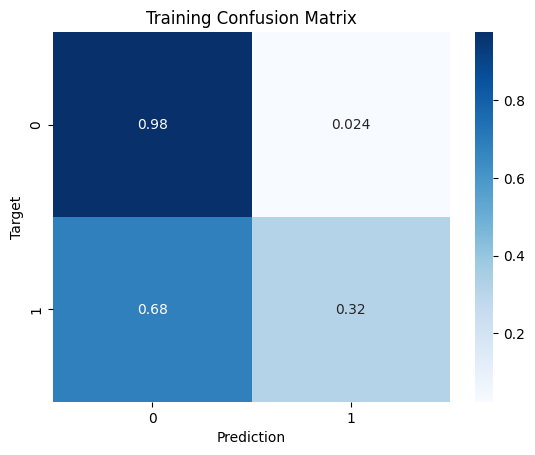

Area under ROC score on Validation dataset: 0.82%


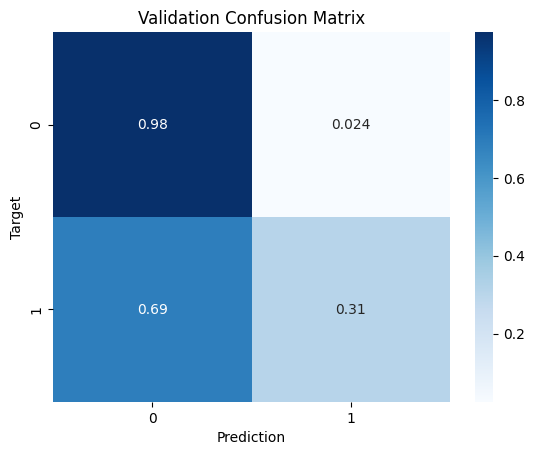

['log_reg_poly_d2.joblib']

In [20]:
numeric_transformer_pf_d_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('pf', PolynomialFeatures(degree=2)),
    ('scaler', MinMaxScaler())
])

preprocessor_pf_d_2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pf_d_2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_pf_d_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_pf_d_2),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_pf_d_2.fit(train_inputs, train_targets)

def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline_pf_d_2.predict(inputs)
    y_pred_proba = model_pipeline_pf_d_2.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_pf_d_2, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline_pf_d_2, val_inputs, val_targets, name='Validation')

joblib.dump(model_pipeline_pf_d_2, 'log_reg_poly_d2.joblib')

**Спостереження**

Overfit не спостерігається, так як модель має близькі метрики для тренувального та валідаційного набору, але напевно вона є недостатньо навченою, так як вгадує лише 31% клієнтів, які дійсно пішли. Але відсоток збільшився після додавання polinomal features, в попередній моделі він був 20%. Тобто можна зробити висновок, що якість покращилася.


**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Training dataset: 0.86%


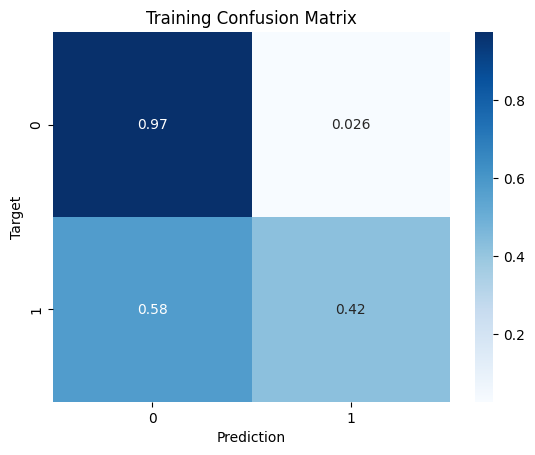

Area under ROC score on Validation dataset: 0.85%


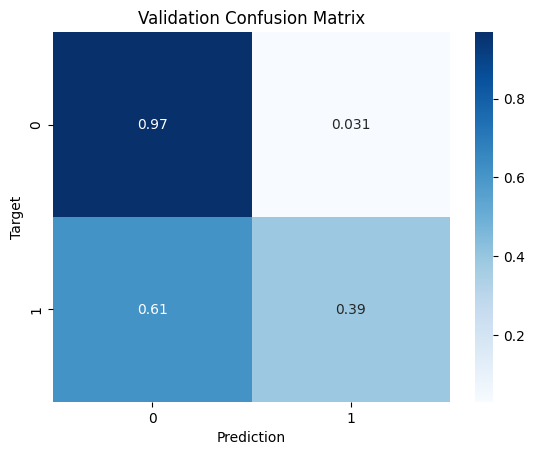

In [21]:
numeric_transformer_pf_d_4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('pf', PolynomialFeatures(degree=4)),
    ('scaler', MinMaxScaler())
])

preprocessor_pf_d_4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pf_d_4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_pf_d_4 = Pipeline(steps=[
    ('preprocessor', preprocessor_pf_d_4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_pf_d_4.fit(train_inputs, train_targets)

def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline_pf_d_4.predict(inputs)
    y_pred_proba = model_pipeline_pf_d_4.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_pf_d_4, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline_pf_d_4, val_inputs, val_targets, name='Validation')

In [22]:
joblib.dump(model_pipeline_pf_d_4, 'log_reg_poly_d4.joblib')

['log_reg_poly_d4.joblib']

**Спостереження**

Тут думаю перенавчання також відсутні, метрики близькі для тренувального та валідаційного набору і відсоток класифікації клієнтів, що йдуть ще покращився до 39% на валідаційному наборі даних.


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [23]:
regression_data = pd.read_csv('/content/regression_data.csv')

In [24]:
regression_data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [25]:
inputs = regression_data.drop('target', axis=1)
targets = regression_data.target
train_inputs, test_inputs, train_targets, test_targets = train_test_split(inputs, targets, test_size=0.2, random_state=17)

In [26]:
def train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=5):
  pipeline = Pipeline(steps=[
      ('scaler', MinMaxScaler()),
      ('pf', PolynomialFeatures(degree=degree)),
      ('model', LinearRegression())
  ])

  pipeline.fit(train_inputs, train_targets)
  y_train_pred = pipeline.predict(train_inputs)
  y_test_pred = pipeline.predict(test_inputs)

  print('Train RMSE:', mean_squared_error(train_targets, y_train_pred) ** 0.5)
  print('Test RMSE:', mean_squared_error(test_targets, y_test_pred) ** 0.5)

  return pipeline

In [27]:
train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=1)

Train RMSE: 1.025451056278157
Test RMSE: 1.0564775321964055


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('pf', PolynomialFeatures(degree=1)),
                ('model', LinearRegression())])

In [28]:
train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=2)

Train RMSE: 0.9904659252058591
Test RMSE: 1.1019921100088725


Pipeline(steps=[('scaler', MinMaxScaler()), ('pf', PolynomialFeatures()),
                ('model', LinearRegression())])

In [29]:
train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=3)

Train RMSE: 0.8037028069758518
Test RMSE: 2.3593509769718155


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('pf', PolynomialFeatures(degree=3)),
                ('model', LinearRegression())])

In [30]:
train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=4)

Train RMSE: 5.784244434857707e-13
Test RMSE: 11.94252374447691


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('pf', PolynomialFeatures(degree=4)),
                ('model', LinearRegression())])

In [31]:
train_lin_reg(train_inputs, test_inputs, train_targets, test_targets, degree=5)

Train RMSE: 2.5015531157086396e-13
Test RMSE: 10.645981839548792


Pipeline(steps=[('scaler', MinMaxScaler()),
                ('pf', PolynomialFeatures(degree=5)),
                ('model', LinearRegression())])

**Спостереження**

З поліноміальними ознаками до степені 2 включно модель генералізує добре, а вже від 3 починає перенавчатися. При 4 і 5 виглядає так, що модель повністю вивчила тренувальні дані і не може працювати на тестових.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [32]:
def train_lasso(train_inputs, test_inputs, train_targets, test_targets, degree=5):
    pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('pf', PolynomialFeatures(degree=degree)),
        ('model', Lasso())
    ])

    pipeline.fit(train_inputs, train_targets)
    y_train_pred = pipeline.predict(train_inputs)
    y_test_pred = pipeline.predict(test_inputs)

    train_rmse = mean_squared_error(train_targets, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(test_targets, y_test_pred) ** 0.5

    return train_rmse, test_rmse

In [33]:
def get_rmse_lasso(train_inputs, test_inputs, train_targets, test_targets, max_degree=20):
    results = []

    for degree in range(1, max_degree + 1):
        train_rmse, test_rmse = train_lasso(
            train_inputs, test_inputs,
            train_targets, test_targets,
            degree=degree
        )

        results.append({
            'Degree': degree,
            'Train RMSE': round(train_rmse, 4),
            'Test RMSE': round(test_rmse, 4)
        })

    return pd.DataFrame(results)

In [34]:
rmse_df_lasso = get_rmse_lasso(train_inputs, test_inputs, train_targets, test_targets)
print(rmse_df_lasso)

    Degree  Train RMSE  Test RMSE
0        1      4.7809     4.7261
1        2      4.7809     4.7261
2        3      4.7809     4.7261
3        4      4.7809     4.7261
4        5      4.7809     4.7261
5        6      4.7809     4.7261
6        7      4.7809     4.7261
7        8      4.7809     4.7261
8        9      4.7809     4.7261
9       10      4.7809     4.7261
10      11      4.7809     4.7261
11      12      4.7809     4.7261
12      13      4.7809     4.7261
13      14      4.7809     4.7261
14      15      4.7809     4.7261
15      16      4.7809     4.7261
16      17      4.7809     4.7261
17      18      4.7809     4.7261
18      19      4.7809     4.7261
19      20      4.7809     4.7261


In [35]:
def train_ridge(train_inputs, test_inputs, train_targets, test_targets, degree=5):
    pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('pf', PolynomialFeatures(degree=degree)),
        ('model', Ridge())
    ])

    pipeline.fit(train_inputs, train_targets)
    y_train_pred = pipeline.predict(train_inputs)
    y_test_pred = pipeline.predict(test_inputs)

    train_rmse = mean_squared_error(train_targets, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(test_targets, y_test_pred) ** 0.5

    return train_rmse, test_rmse

In [36]:
def get_rmse_ridge(train_inputs, test_inputs, train_targets, test_targets, max_degree=20):
    results = []

    for degree in range(1, max_degree + 1):
        train_rmse, test_rmse = train_ridge(
            train_inputs, test_inputs,
            train_targets, test_targets,
            degree=degree
        )

        results.append({
            'Degree': degree,
            'Train RMSE': round(train_rmse, 4),
            'Test RMSE': round(test_rmse, 4)
        })

    return pd.DataFrame(results)

In [37]:
rmse_df_ridge = get_rmse_ridge(train_inputs, test_inputs, train_targets, test_targets)
print(rmse_df_ridge)

    Degree  Train RMSE  Test RMSE
0        1      8.0045     8.0477
1        2      5.4221     6.5795
2        3      6.5986     7.8404
3        4      6.7464     8.2193
4        5      6.3964     8.1944
5        6      6.0740     8.1007
6        7      5.8979     8.0271
7        8      5.8303     7.9852
8        9      5.8179     7.9692
9       10      5.8267     7.9717
10      11      5.8408     7.9885
11      12      5.8542     8.0176
12      13      5.8650     8.0579
13      14      5.8732     8.1082
14      15      5.8793     8.1670
15      16      5.8837     8.2325
16      17      5.8868     8.3028
17      18      5.8890     8.3761
18      19      5.8904     8.4506
19      20      5.8913     8.5246


In [38]:
def train_elastic(train_inputs, test_inputs, train_targets, test_targets, degree=5):
    pipeline = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('pf', PolynomialFeatures(degree=degree)),
        ('model', ElasticNet())
    ])

    pipeline.fit(train_inputs, train_targets)
    y_train_pred = pipeline.predict(train_inputs)
    y_test_pred = pipeline.predict(test_inputs)

    train_rmse = mean_squared_error(train_targets, y_train_pred) ** 0.5
    test_rmse = mean_squared_error(test_targets, y_test_pred) ** 0.5

    return train_rmse, test_rmse

In [39]:
def get_rmse_elastic(train_inputs, test_inputs, train_targets, test_targets, max_degree=20):
    results = []

    for degree in range(1, max_degree + 1):
        train_rmse, test_rmse = train_elastic(
            train_inputs, test_inputs,
            train_targets, test_targets,
            degree=degree
        )

        results.append({
            'Degree': degree,
            'Train RMSE': round(train_rmse, 4),
            'Test RMSE': round(test_rmse, 4)
        })

    return pd.DataFrame(results)

In [40]:
rmse_df_elastic = get_rmse_elastic(train_inputs, test_inputs, train_targets, test_targets)
print(rmse_df_elastic)

    Degree  Train RMSE  Test RMSE
0        1     41.6472    41.5980
1        2     36.9533    37.2851
2        3     33.5593    34.3484
3        4     31.7014    32.7820
4        5     30.8330    32.0174
5        6     30.4516    31.6417
6        7     30.2764    31.4431
7        8     30.1873    31.3266
8        9     30.1354    31.2527
9       10     30.1025    31.2033
10      11     30.0801    31.1700
11      12     30.0640    31.1486
12      13     30.0515    31.1373
13      14     30.0416    31.1358
14      15     30.0335    31.1445
15      16     30.0267    31.1645
16      17     30.0208    31.1976
17      18     30.0157    31.2464
18      19     30.0112    31.3142
19      20     30.0070    31.4054


**Спостереження**

Виглядає так, що найкраще генералізує проста LinearRegression(), вона має найнижче значення RMSE і невелику різницю цієї ж метрики між Train і Test.